In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
import cv2
import os


In [2]:
# Loading the datasets
categories = ['Cardboard', 'Food Organics' ,'Glass' , 'Metal', 'Miscellaneous Trash', 'Paper' , 'Plastic' ,'Textile Trash']
labels = {cat : index for index , cat in enumerate(categories)}

images_per_category=[[],[],[],[],[],[],[],[]]
images_per_category_label=[[],[],[],[],[],[],[],[]]

for index , cat in enumerate(categories):
    basefolder ="RealWaste/"
    sub_directory = os.path.join(basefolder,cat)
    sub_list = os.listdir(sub_directory)

    for image_path in sub_list:
        full_image_path =os.path.join(sub_directory,image_path)
        image_array = cv2.imread(full_image_path)
        images_per_category[index].append(image_array)
        images_per_category_label[index].append(index)



In [3]:
len(images_per_category[0])
len(images_per_category_label[0])

461

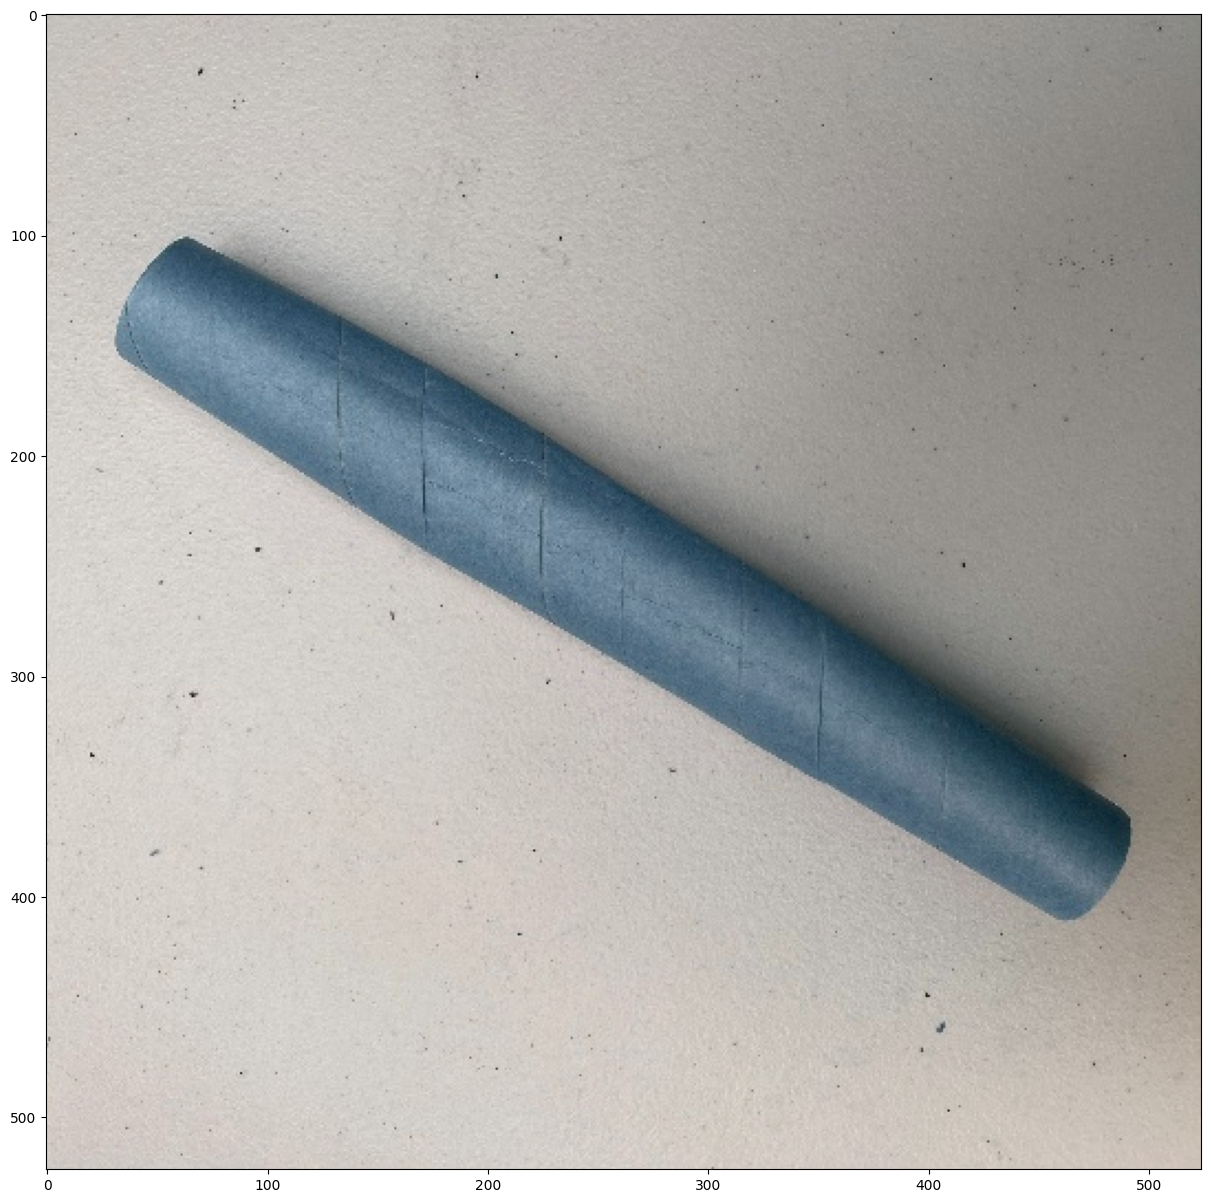

In [95]:
plt.figure(figsize=(15,15))
plt.imshow(images_per_category[0][0])

Merging the list

In [4]:
all_image=[]
all_image_label=[]
for image_set , label_set in zip(images_per_category,images_per_category_label):
    for per_image , per_label in zip(image_set,label_set):
        all_image.append(per_image)
        all_image_label.append(per_label)

print('Total Number of images : ' , len(all_image))


Total Number of images :  4316


Preprocessing the images --> Resizing

In [5]:
len(all_image[0])

524

In [166]:
target_width = 256
target_height = 256

for index , image in enumerate(all_image):
    all_image[index] = cv2.resize(image ,(target_height,target_width),interpolation=cv2.INTER_AREA)


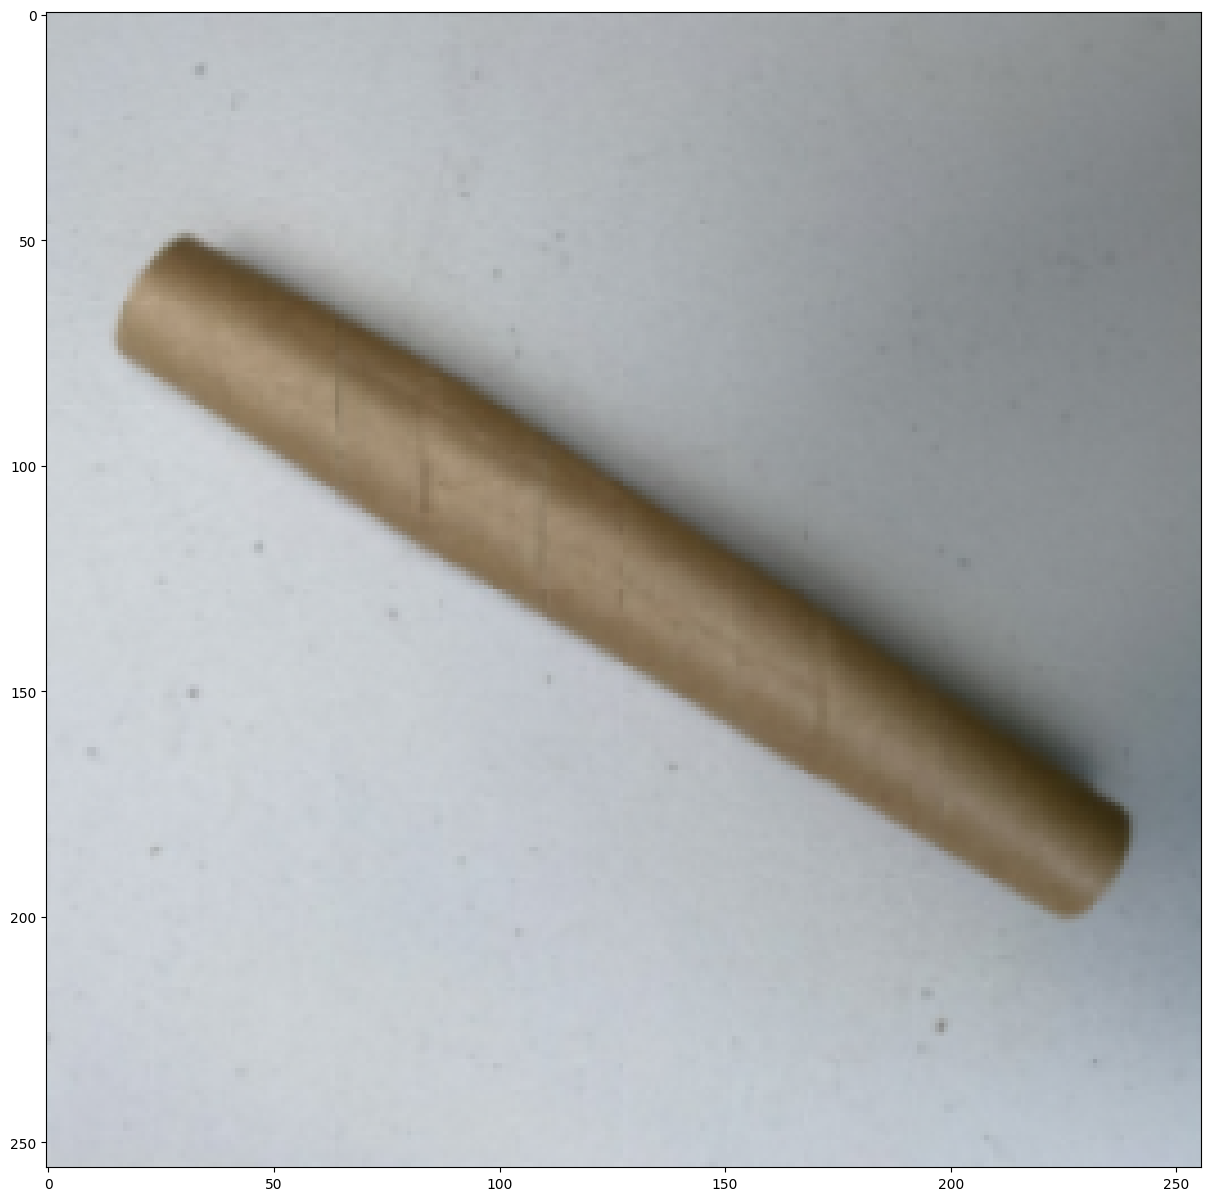

In [167]:
plt.figure(figsize=(15,15))
plt.imshow(all_image[0])

In [168]:
len(all_image[0])

256

Converting the color of image from BGR ---> RGB

In [133]:
for index , image in enumerate(all_image):
    all_image[index] = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)

Reducing the Noise in Image

In [169]:
guassian_sample=[]
median_blur=[]
bilateral_filter=[]
for index , image in enumerate(all_image):
    #guassian_sample.append(cv2.GaussianBlur(image, ksize=(5,5), sigmaX=0))
    #median_blur.append(cv2.medianBlur(image,ksize=5))
    bilateral_filter.append(cv2.bilateralFilter(image ,d=7 , sigmaColor= 50,sigmaSpace=50))

Visualizing the Images

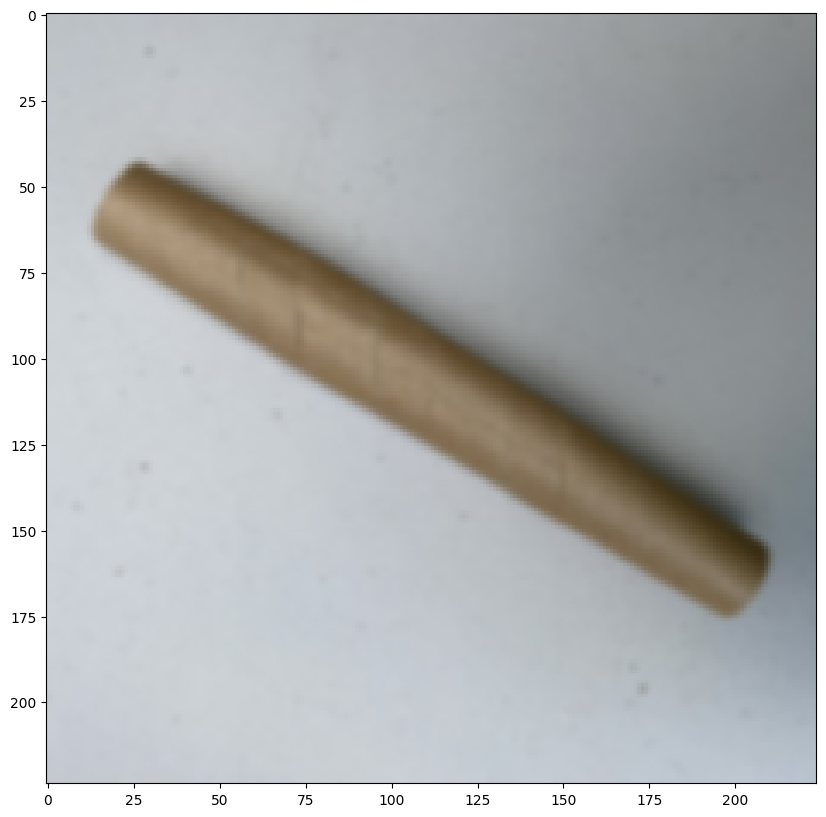

In [100]:
#Guassian blur
plt.figure(figsize=(10,10))
plt.imshow(guassian_sample[0])

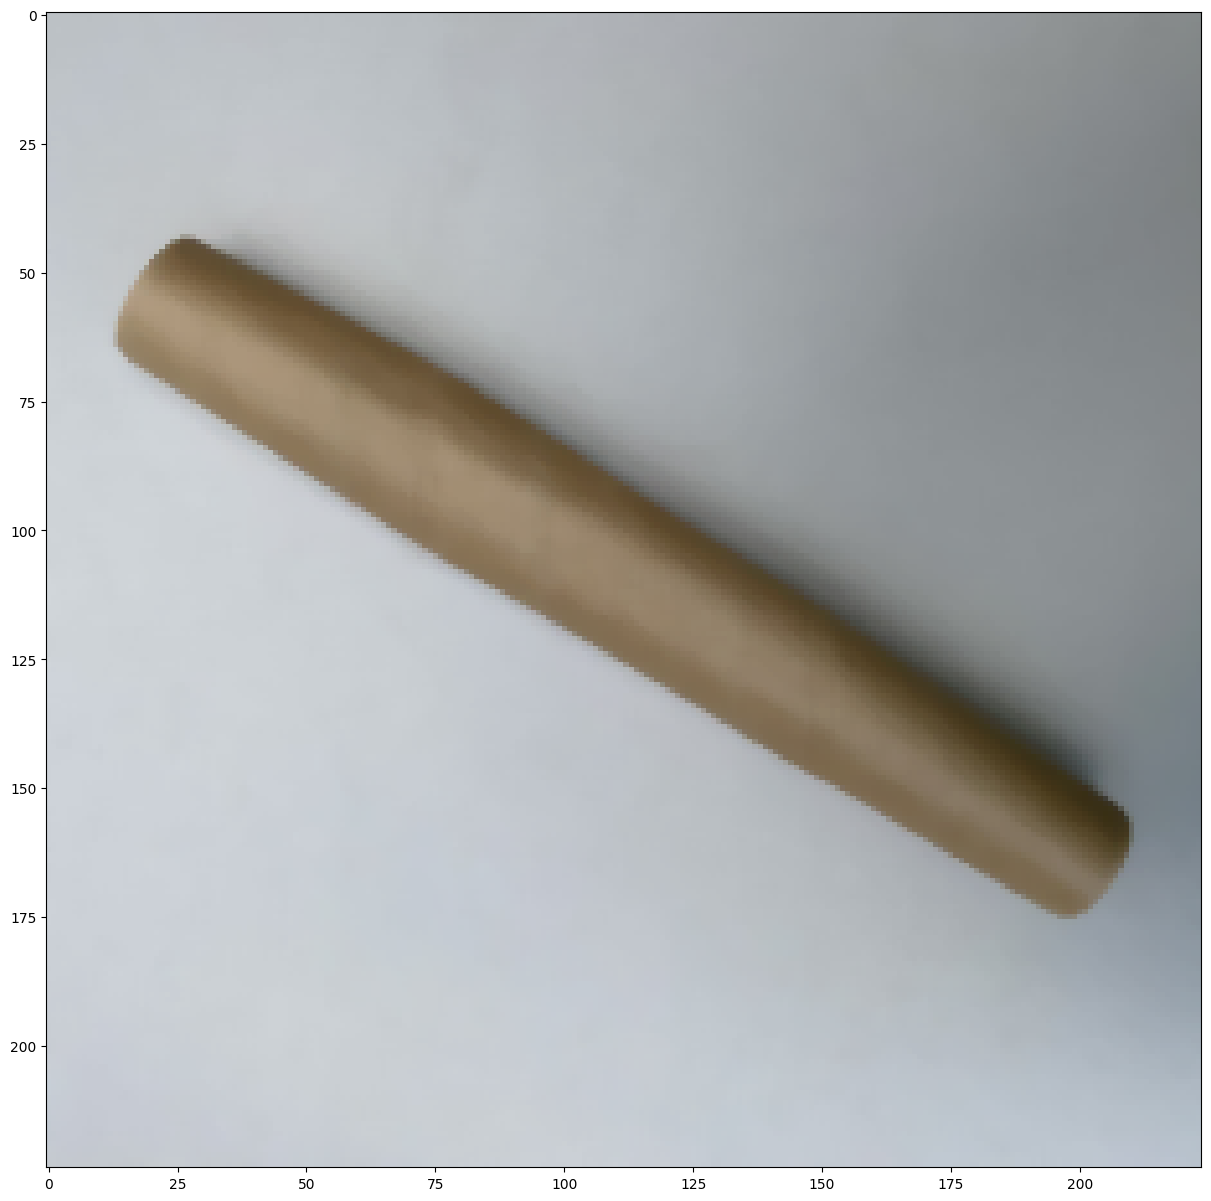

In [107]:
#median blur
plt.figure(figsize=(15,15))
plt.imshow(median_blur[0])

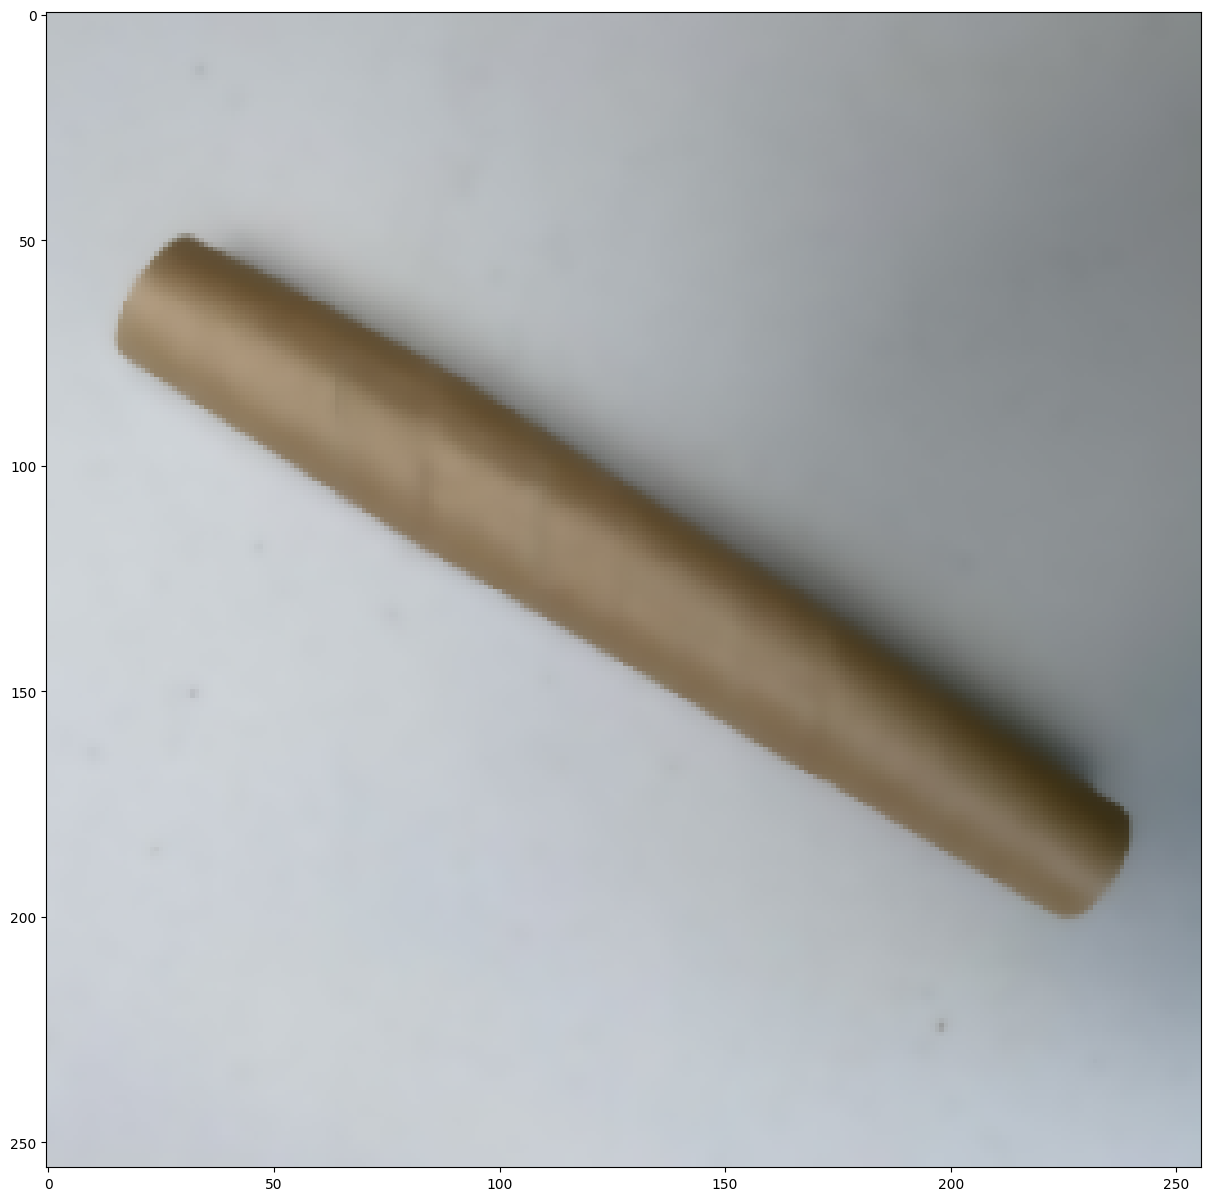

In [170]:
#Bilateral filter
plt.figure(figsize=(15,15))
plt.imshow(bilateral_filter[0])

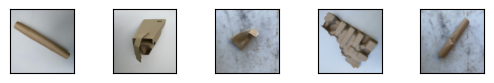

In [12]:

for i in range(5):
    plt.subplot(5,5,i+1)
    plt.imshow(bilateral_filter[i])
    plt.xticks([])
    plt.yticks([])
       
plt.show()

Applying the CLAHE (contrast enhancement technique)

In [207]:
# creating the object of clahe
clahe = cv2.createCLAHE(clipLimit=2.0 , tileGridSize=(9,9))
clahe_image_list = []

for index , image in enumerate(bilateral_filter):
    #converting the image from rgb to lab 
    image_lab = cv2.cvtColor(image,cv2.COLOR_RGB2LAB)
    #splitting the image into 3 channels
    L_channel,A_channel,B_channel = cv2.split(image_lab)
    #applying the clahe technique to only L_channel(light)
    clahe_L_channel = clahe.apply(L_channel)
    #Merging al 3 channels together
    clahe_image = cv2.merge((clahe_L_channel,A_channel,B_channel))
    #converting the image from lab to rgb
    clahe_image_rgb = cv2.cvtColor(clahe_image,cv2.COLOR_LAB2RGB)
    #Appending all enhanced images into single list 
    clahe_image_list.append(clahe_image_rgb)


In [ ]:
clahe_image_list[0]

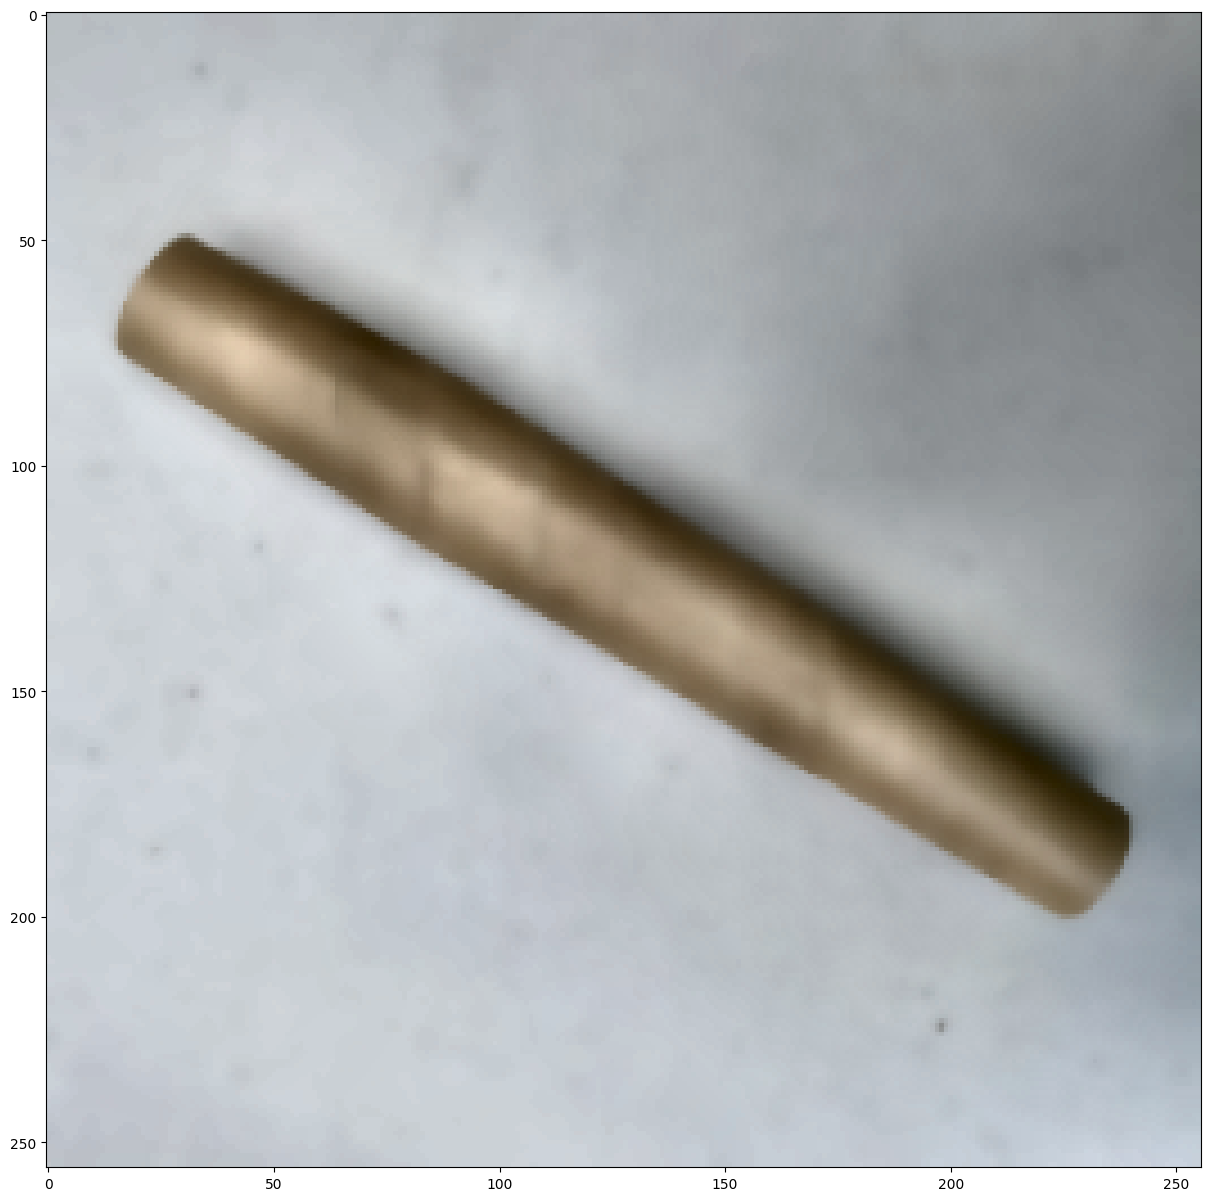

In [208]:
#viual image After clahe
plt.figure(figsize=(15,15))

plt.imshow(clahe_image_list[0])

plt.show()

Sharpening the edges

In [209]:
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

for index,image in enumerate(clahe_image_list):
    clahe_image_list[index] = cv2.filter2D(image, -1, kernel)

In [210]:
clahe_image_list[0]

array([[[170, 171, 180],
        [188, 195, 198],
        [185, 191, 195],
        ...,
        [142, 148, 148],
        [133, 139, 139],
        [132, 144, 142]],

       [[188, 195, 198],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [143, 152, 151],
        [129, 141, 139],
        [146, 137, 142]],

       [[185, 191, 195],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [138, 132, 136],
        [144, 138, 142],
        [130, 145, 142]],

       ...,

       [[189, 194, 203],
        [192, 193, 201],
        [192, 193, 201],
        ...,
        [196, 208, 224],
        [202, 207, 216],
        [201, 207, 218]],

       [[196, 188, 189],
        [183, 197, 203],
        [186, 196, 201],
        ...,
        [197, 208, 222],
        [200, 208, 216],
        [199, 208, 218]],

       [[207, 212, 215],
        [183, 192, 199],
        [188, 195, 201],
        ...,
        [193, 205, 219],
        [200, 208, 216],
        [199, 208, 218]]

Normalizing the images

In [211]:
X_dataset = np.array(clahe_image_list)
Y_dataset = np.array(all_image_label)
X_dataset[0]


array([[[170, 171, 180],
        [188, 195, 198],
        [185, 191, 195],
        ...,
        [142, 148, 148],
        [133, 139, 139],
        [132, 144, 142]],

       [[188, 195, 198],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [143, 152, 151],
        [129, 141, 139],
        [146, 137, 142]],

       [[185, 191, 195],
        [185, 191, 195],
        [185, 191, 195],
        ...,
        [138, 132, 136],
        [144, 138, 142],
        [130, 145, 142]],

       ...,

       [[189, 194, 203],
        [192, 193, 201],
        [192, 193, 201],
        ...,
        [196, 208, 224],
        [202, 207, 216],
        [201, 207, 218]],

       [[196, 188, 189],
        [183, 197, 203],
        [186, 196, 201],
        ...,
        [197, 208, 222],
        [200, 208, 216],
        [199, 208, 218]],

       [[207, 212, 215],
        [183, 192, 199],
        [188, 195, 201],
        ...,
        [193, 205, 219],
        [200, 208, 216],
        [199, 208, 218]]

In [214]:
X_dataset = X_dataset.astype(np.float32)/255.0
X_dataset

MemoryError: Unable to allocate 3.16 GiB for an array with shape (4316, 256, 256, 3) and data type float32

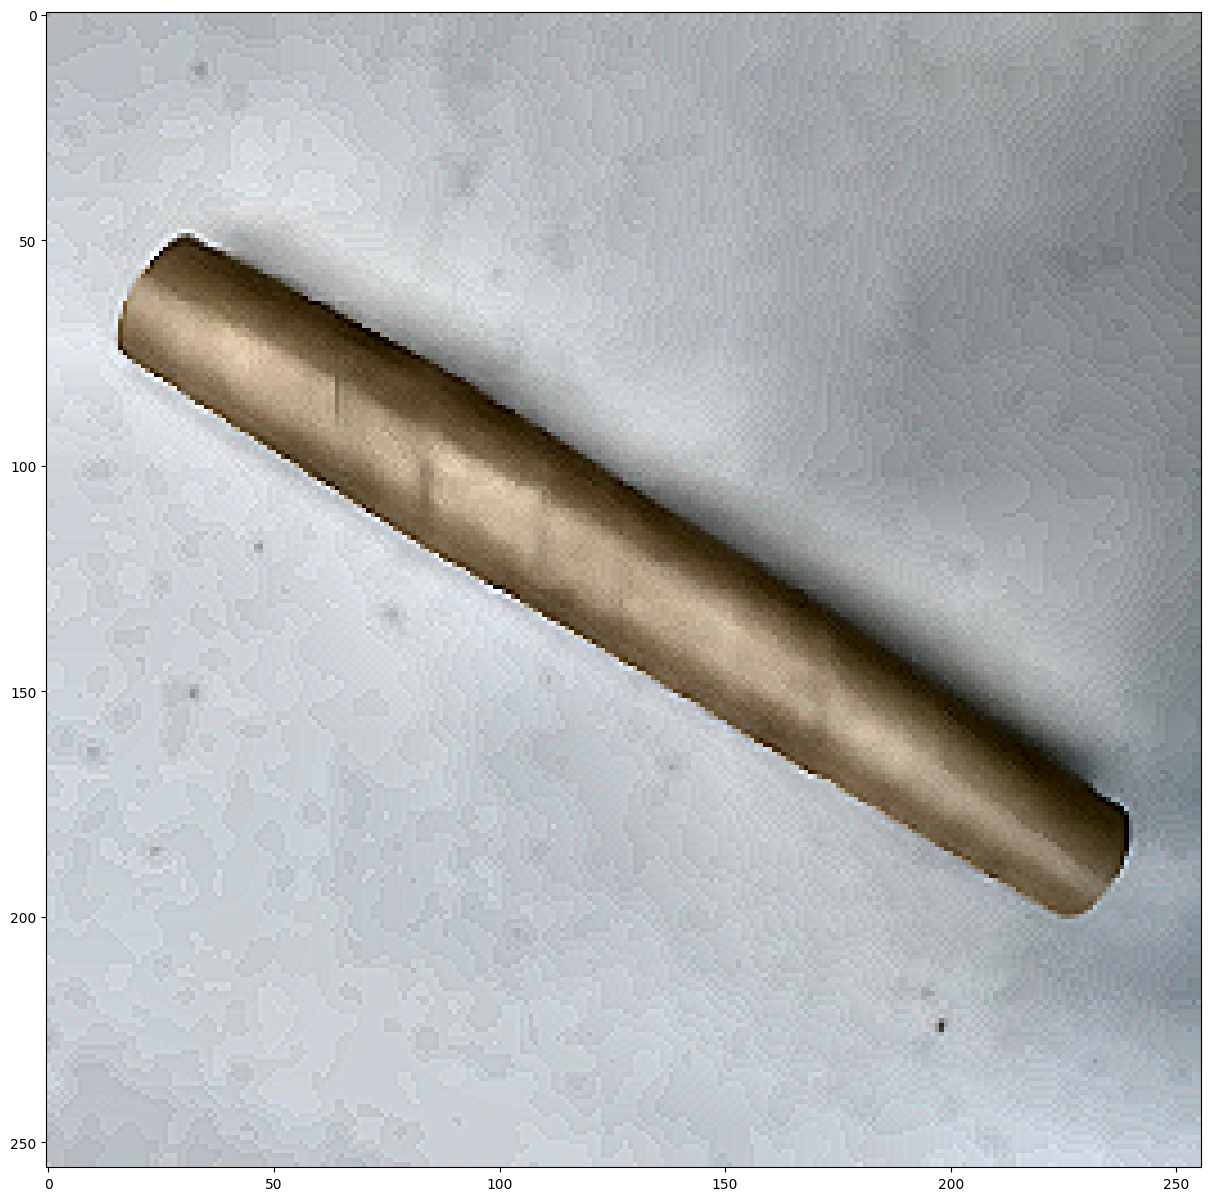

In [ ]:
plt.figure(figsize=(15,15))
plt.imshow(X_dataset[0])